In [23]:
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

In [24]:

test = pd.read_csv("data/test.csv")
train = pd.read_csv("data/train.csv")

In [25]:
train.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


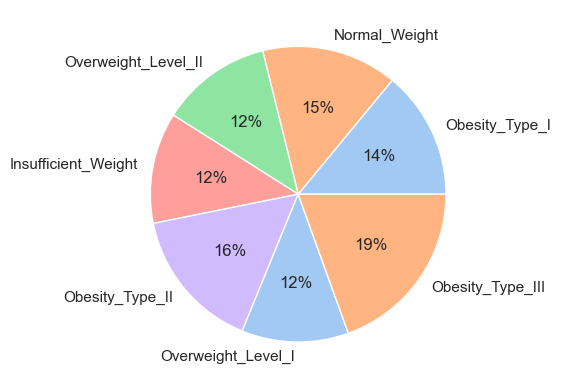

In [26]:
def pie(table):
    label = list(set(table.values))

    data = []

    for name_d in label:
        data.append(table.apply(lambda x: 1 if x == name_d else 0).sum())

    colors = sns.color_palette('pastel')[ 0:5 ]

    plt.pie(data, labels=label, colors=colors, autopct='%.0f%%')
    plt.show()

pie(train.NObeyesdad)



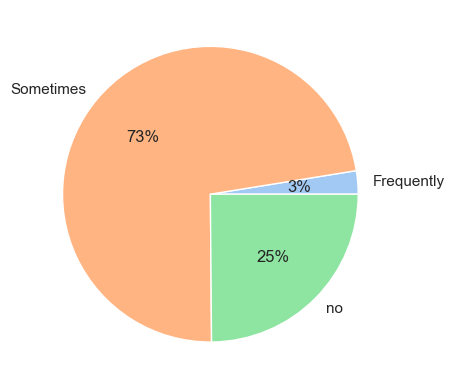

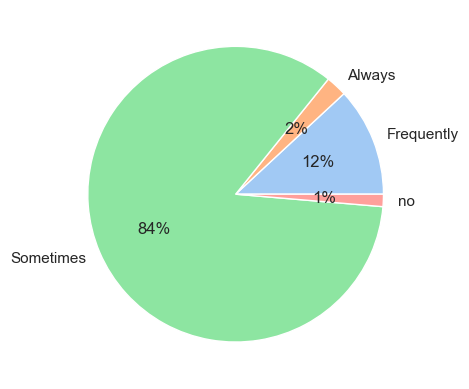

In [27]:
pie(train.CALC)
pie(train.CAEC)

<Axes: xlabel='Age', ylabel='Weight'>

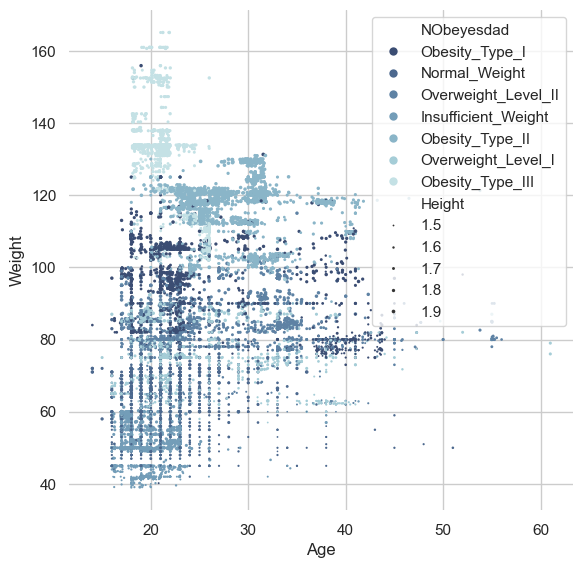

In [28]:

sns.set_theme(style="whitegrid")

data = train

f, ax = plt.subplots(figsize=(6.5, 6.5))

sns.despine(f, left=True, bottom=True)

clarity_ranking = list(set(train.NObeyesdad.values))

sns.scatterplot(x="Age", y="Weight",
                hue="NObeyesdad", size="Height",
                palette="ch:r=-.2,d=.3_r",
                hue_order=clarity_ranking,
                sizes=(1, 8), linewidth=0,
                data=data, ax=ax)



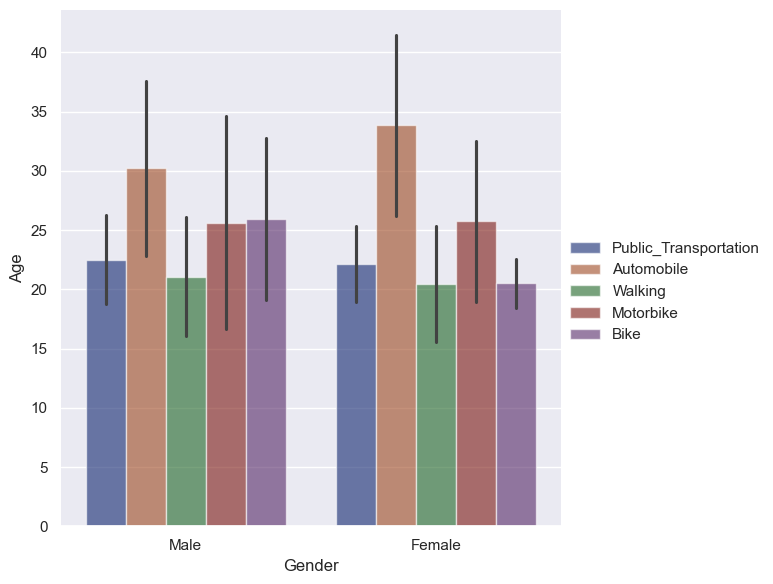

In [29]:

sns.set_theme(style="darkgrid")

g = sns.catplot(
    data=train, kind="bar",
    x="Gender", y="Age", hue="MTRANS",
    errorbar="sd", palette="dark", alpha=.6, height=6
)
g.despine(left=True)
g.legend.set_title("")



In [30]:
train.isna().sum()

id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [31]:
def models(num_feauter, num_class):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(num_feauter, input_dim=num_feauter, ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.Dropout(.2),
        
        tf.keras.layers.Dense(256),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.Dropout(.2),
        
        tf.keras.layers.Dense(num_class, activation="softmax"),
    ])
    
    return model

In [32]:
table = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]

for name in table:
    train[name] = train[name].apply(lambda x: {"yes": 1, "no": 0}[x])

train.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,Sometimes,0,2.763573,0,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,Frequently,0,2.000000,0,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,Sometimes,0,1.910378,0,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,Sometimes,0,1.674061,0,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,Sometimes,0,1.979848,0,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [33]:
clean_data = {"no": 0, "Always": 1, "Frequently": 2, "Sometimes": 3,}

train.CALC = train.CALC.map(clean_data)
train.CAEC =  train.CAEC.map(clean_data)

train.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,3,0,2.763573,0,0.000000,0.976473,3,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,2,0,2.000000,0,1.000000,1.000000,0,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,3,0,1.910378,0,0.866045,1.673584,0,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,3,0,1.674061,0,1.467863,0.780199,3,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,3,0,1.979848,0,1.967973,0.931721,3,Public_Transportation,Overweight_Level_II


In [34]:
clean_data = {"Male": 0, "Female": 1}

train.Gender = train.Gender.map(clean_data)

train.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,0,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,3,0,2.763573,0,0.000000,0.976473,3,Public_Transportation,Overweight_Level_II
1,1,1,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,2,0,2.000000,0,1.000000,1.000000,0,Automobile,Normal_Weight
2,2,1,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,3,0,1.910378,0,0.866045,1.673584,0,Public_Transportation,Insufficient_Weight
3,3,1,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,3,0,1.674061,0,1.467863,0.780199,3,Public_Transportation,Obesity_Type_III
4,4,0,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,3,0,1.979848,0,1.967973,0.931721,3,Public_Transportation,Overweight_Level_II


In [35]:
transport_mapping = {
    'Bike': 0,
    'Walking': 1,
    'Public_Transportation': 2,
    'Automobile': 3,
    'Motorbike': 4,
}

train['MTRANS'] = train['MTRANS'].map(transport_mapping)

train.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,0,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,3,0,2.763573,0,0.000000,0.976473,3,2,Overweight_Level_II
1,1,1,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,2,0,2.000000,0,1.000000,1.000000,0,3,Normal_Weight
2,2,1,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,3,0,1.910378,0,0.866045,1.673584,0,2,Insufficient_Weight
3,3,1,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,3,0,1.674061,0,1.467863,0.780199,3,2,Obesity_Type_III
4,4,0,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,3,0,1.979848,0,1.967973,0.931721,3,2,Overweight_Level_II


In [36]:

target_mapping = {
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6,
}

train['NObeyesdad'] = train['NObeyesdad'].map(target_mapping)

train.head()



,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,0,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,3,0,2.763573,0,0.000000,0.976473,3,2,3
1,1,1,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,2,0,2.000000,0,1.000000,1.000000,0,3,1
2,2,1,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,3,0,1.910378,0,0.866045,1.673584,0,2,0
3,3,1,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,3,0,1.674061,0,1.467863,0.780199,3,2,6
4,4,0,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,3,0,1.979848,0,1.967973,0.931721,3,2,3


In [37]:

def ss(data):
    return (data - data.mean()) / data.std()

train.Age = ss(train.Age)
train.Weight = ss(train.Weight)
train.Height = ss(train.Height)
train.FCVC = ss(train.FCVC)
train.NCP = ss(train.NCP)
train.CAEC = ss(train.CAEC)
train.CH2O = ss(train.CH2O)
train.CALC = ss(train.CALC)
train.MTRANS = ss(train.MTRANS)

train.head()



,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,0,0.105696,-0.002828,-0.235707,1,1,-0.836259,0.314676,0.381561,0,1.206565,0,0.000000,0.976473,0.597370,-0.345566,3
1,1,1,-1.027027,-1.606252,-1.170903,1,1,-0.836259,0.338356,-1.475520,0,-0.048348,0,1.000000,1.000000,-1.725056,1.984169,1
2,2,1,-1.027027,0.128448,-1.429978,1,1,-1.060306,-1.913377,0.381561,0,-0.195640,0,0.866045,1.673584,-1.725056,-0.345566,0
3,3,1,-0.507917,0.120087,1.644731,1,1,1.039146,0.338356,0.381561,0,-0.584021,0,1.467863,0.780199,0.597370,-0.345566,6
4,4,0,1.371163,2.450308,0.224049,1,1,0.438386,-1.119774,0.381561,0,-0.081467,0,1.967973,0.931721,0.597370,-0.345566,3


In [46]:
x = train.drop(['id', 'NObeyesdad'], axis=1)
y = train['NObeyesdad']

X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=.2, random_state=20)

x.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,0,0.105696,-0.002828,-0.235707,1,1,-0.836259,0.314676,0.381561,0,1.206565,0,0.000000,0.976473,0.597370,-0.345566
1,1,-1.027027,-1.606252,-1.170903,1,1,-0.836259,0.338356,-1.475520,0,-0.048348,0,1.000000,1.000000,-1.725056,1.984169
2,1,-1.027027,0.128448,-1.429978,1,1,-1.060306,-1.913377,0.381561,0,-0.195640,0,0.866045,1.673584,-1.725056,-0.345566
3,1,-0.507917,0.120087,1.644731,1,1,1.039146,0.338356,0.381561,0,-0.584021,0,1.467863,0.780199,0.597370,-0.345566
4,0,1.371163,2.450308,0.224049,1,1,0.438386,-1.119774,0.381561,0,-0.081467,0,1.967973,0.931721,0.597370,-0.345566


In [39]:
model = models(x.shape[1], 7)
pca = PCA(n_components=.99)
pca.fit(X_train)

model.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
              loss=tf.keras.losses.CategoricalFocalCrossentropy(),
              metrics=['accuracy'])

E:\Multi-ClassPredictionOfObesityRisk\.venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model.fit(X_train, tf.keras.utils.to_categorical(y_train, 7), epochs=25, validation_data=(X_val, tf.keras.utils.to_categorical(y_val, 7)))

Epoch 1/25
519/519 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.3986 - loss: 0.2734 - val_accuracy: 0.6325 - val_loss: 0.1272
Epoch 2/25
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5736 - loss: 0.1593 - val_accuracy: 0.6883 - val_loss: 0.0993
Epoch 3/25
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6004 - loss: 0.1373 - val_accuracy: 0.7375 - val_loss: 0.0853
Epoch 4/25
519/519 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6405 - loss: 0.1168 - val_accuracy: 0.7661 - val_loss: 0.0749
Epoch 5/25
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6638 - loss: 0.1076 - val_accuracy: 0.7890 - val_loss: 0.0675
Epoch 6/25
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6736 - loss: 0.0990 - val_accuracy: 0.8107 - val_loss: 0.0626
Epoch 7/25
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7003 - loss: 0.0917 - val_accuracy: 0.8066 - val_loss: 0.0595
Epoch 8/25
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7057 - loss: 0.0878 - val_accuracy: 0.

In [41]:
table = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]

for name in table:
    test[name] = test[name].apply(lambda x: {"yes": 1, "no": 0}[x])


clean_data = {"no": 0, "Always": 1, "Frequently": 2, "Sometimes": 3,}

test.CALC = test.CALC.map(clean_data)
test.CAEC = test.CAEC.map(clean_data)

clean_data = {"Male": 0, "Female": 1}

test.Gender = test.Gender.map(clean_data)

transport_mapping = {
    'Bike': 0,
    'Walking': 1,
    'Public_Transportation': 2,
    'Automobile': 3,
    'Motorbike': 4,
}

test['MTRANS'] = test['MTRANS'].map(transport_mapping)

test.Age = ss(test.Age)
test.Weight = ss(test.Weight)
test.Height = ss(test.Height)
test.FCVC = ss(test.FCVC)
test.NCP = ss(test.NCP)
test.CAEC = ss(test.CAEC)
test.CH2O = ss(test.CH2O)
test.CALC = ss(test.CALC)
test.MTRANS = ss(test.MTRANS)

test.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,20758,0,0.508145,1.682728,1.273740,1,1,0.932491,0.350795,0.382608,0,1.298342,0,0.855400,0.000000,0.605008,-0.35648
1,20759,1,-0.509109,-1.114617,-0.818959,1,1,-0.833131,-2.462434,0.382608,0,1.583621,0,1.000000,0.000000,0.605008,-0.35648
2,20760,1,0.352987,-0.626169,0.927398,1,1,1.047960,0.350795,0.382608,0,0.964994,0,0.000000,0.250502,0.605008,-0.35648
3,20761,0,-0.512686,-1.642701,0.623649,1,1,-0.833131,0.319722,0.382608,0,1.234189,0,0.094851,0.000000,0.605008,-0.35648
4,20762,1,0.352987,-0.805967,0.668312,1,1,1.047960,0.350795,0.382608,0,1.016782,0,0.000000,0.741069,0.605008,-0.35648


In [42]:
classes = {0: 'Insufficient_Weight',
 1: 'Normal_Weight',
 2: 'Overweight_Level_I',
 3: 'Overweight_Level_II',
 4: 'Obesity_Type_I',
 5: 'Obesity_Type_II',
 6: 'Obesity_Type_III'}

x = np.array(test.drop(['id'], axis=1))

final_output = pd.read_csv('data/sample_submission.csv')

final_output.NObeyesdad = [classes[tf.argmax(i).numpy()] for i in model(x)]

final_output

,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III
...,...,...
13835,34593,Overweight_Level_II
13836,34594,Overweight_Level_I
13837,34595,Insufficient_Weight
13838,34596,Normal_Weight


In [43]:


set(final_output.NObeyesdad.values)



{'Insufficient_Weight',
 'Normal_Weight',
 'Obesity_Type_I',
 'Obesity_Type_II',
 'Obesity_Type_III',
 'Overweight_Level_I',
 'Overweight_Level_II'}

In [44]:

final_output.to_csv('submission.csv', index=False)